# 🔍 Applied Explainable AI (XAI)
### PDP · ICE · PFI · LIME · SHAP
ICE — Individual Conditional Expectation

PDP — Partial Dependence Plot

PFI — Permutation Feature Importance

LIME - Local Interpretable Model agnostic Explanations

SHAP - SHapley Additive exPlanations
---


**Format:** Concept → Code → Interpret → Discuss

---


---

## 🏦 Our Business Problem: Loan Default Prediction

A bank has trained a machine learning model to predict whether a customer will **default on a loan**.
The model works well, but the bank's compliance team — and the customers — want to know **WHY** a loan is approved or rejected.

This is exactly the problem XAI is built to solve.

> **Features in our dataset:**
> - `age` — Customer age
> - `income` — Annual income (in $000s)
> - `loan_amount` — Requested loan (in $000s)
> - `credit_score` — Credit score (300–850)
> - `employment_years` — Years at current job
> - `debt_to_income` — Existing debt as % of income
> - `num_credit_lines` — Number of active credit lines
>
> **Target:** `default` — 1 = defaulted, 0 = repaid


---
## ⚙️ Section 0: Setup

### Install & Import Libraries

The cell below installs and imports everything we need for the entire session.
We use:
- **`scikit-learn`** — for building our ML model
- **`pandas` / `numpy`** — for data handling
- **`matplotlib` / `seaborn`** — for visualisations
- **`shap`** — for SHAP explanations
- **`lime`** — for LIME explanations

Run this cell first — it only needs to run once.

In [ ]:
# Install required libraries (run once)
!pip install shap lime scikit-learn pandas numpy matplotlib seaborn --quiet

# Core data libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

# XAI Libraries
import shap
import lime
import lime.lime_tabular

# Settings
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
shap.initjs()   # Enables interactive SHAP plots in the notebook

print("✅ All libraries loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


✅ All libraries loaded successfully!


### 📊 Create Our Loan Dataset

We'll generate a **realistic synthetic dataset** so we have full control and can focus on interpretation rather than data wrangling.

The data is designed to reflect real-world loan patterns:
- Higher income → less likely to default
- Higher debt-to-income ratio → more likely to default
- Higher credit score → less likely to default

This means our model will learn **genuinely meaningful patterns** — and our XAI explanations will make business sense.

In [ ]:
# ── Create Synthetic Loan Dataset ──────────────────────────────────────────
np.random.seed(42)
n = 1500

age               = np.random.randint(22, 65, n)
income            = np.random.normal(65, 25, n).clip(20, 180)          # $000s
loan_amount       = np.random.normal(25, 12, n).clip(5, 80)            # $000s
credit_score      = np.random.normal(650, 80, n).clip(300, 850).astype(int)
employment_years  = np.random.exponential(5, n).clip(0, 30).round(1)
debt_to_income    = np.random.beta(2, 5, n) * 60                       # 0–60%
num_credit_lines  = np.random.randint(1, 12, n)

# Default probability — driven by real-world logic
# Intercept (0.8) and credit_score coefficient (-0.004) are calibrated
# so the dataset has a realistic ~20% default rate
log_odds = (
    0.8                            # intercept — calibrated for ~20% default rate
    - 0.015 * income
    + 0.025 * loan_amount
    - 0.004 * credit_score         # reduced from -0.008 to avoid near-zero default rate
    + 0.045 * debt_to_income
    - 0.04  * employment_years
    + 0.01  * age
    - 0.05  * num_credit_lines
    + np.random.normal(0, 0.4, n)  # noise
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (np.random.rand(n) < prob_default).astype(int)

# Assemble DataFrame
df = pd.DataFrame({
    'age':              age,
    'income':           income.round(1),
    'loan_amount':      loan_amount.round(1),
    'credit_score':     credit_score,
    'employment_years': employment_years,
    'debt_to_income':   debt_to_income.round(2),
    'num_credit_lines': num_credit_lines,
    'default':          default
})

print(f"Dataset shape: {df.shape}")
print(f"Default rate:  {df['default'].mean():.1%}")
df.head(8)

Dataset shape: (1500, 8)
Default rate:  21.3%


,age,income,loan_amount,credit_score,employment_years,debt_to_income,num_credit_lines,default
0,60,71.0,17.3,771,0.7,25.36,7,0
1,50,72.6,45.4,681,1.3,6.98,1,1
2,36,88.3,11.7,606,13.5,10.10,4,0
3,64,75.5,5.1,735,9.8,32.33,10,1
4,29,75.1,15.1,742,6.2,31.01,1,1
5,42,82.9,17.0,632,3.3,12.33,4,0
6,60,77.6,5.0,745,3.7,14.07,3,0
7,40,86.4,23.5,605,18.5,15.55,2,0


### 📈 Quick Exploratory Look

Before we train any model, let's get a feel for how features relate to loan defaults.
This helps us later verify that our XAI explanations make intuitive sense — a critical sanity check.

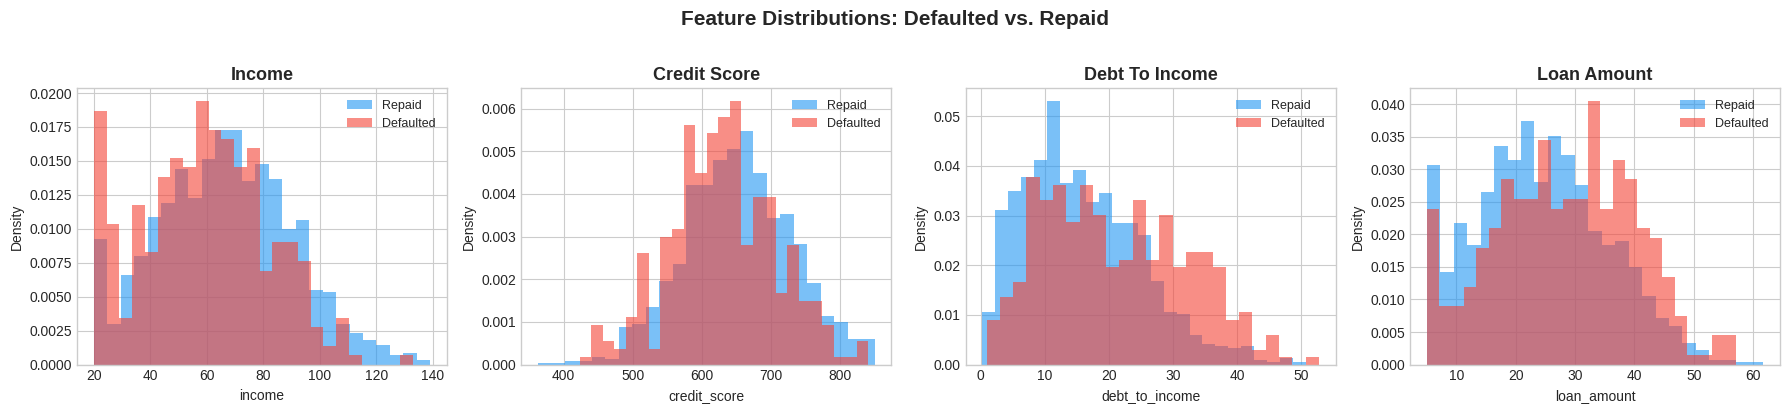


📌 Observations:
  • Avg income    — Repaid: $67k  |  Defaulted: $59k
  • Avg credit    — Repaid: 653    |  Defaulted: 631
  • Avg DTI       — Repaid: 15.9%  |  Defaulted: 21.1%


In [ ]:
# ── Quick EDA: Feature distributions by default status ─────────────────────
features_to_plot = ['income', 'credit_score', 'debt_to_income', 'loan_amount']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

colors = {0: '#2196F3', 1: '#F44336'}
labels = {0: 'Repaid', 1: 'Defaulted'}

for ax, feat in zip(axes, features_to_plot):
    for status in [0, 1]:
        subset = df[df['default'] == status][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=colors[status],
                label=labels[status], density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions: Defaulted vs. Repaid', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Key observations
print("\n📌 Observations:")
print(f"  • Avg income    — Repaid: ${df[df.default==0].income.mean():.0f}k  |  Defaulted: ${df[df.default==1].income.mean():.0f}k")
print(f"  • Avg credit    — Repaid: {df[df.default==0].credit_score.mean():.0f}    |  Defaulted: {df[df.default==1].credit_score.mean():.0f}")
print(f"  • Avg DTI       — Repaid: {df[df.default==0].debt_to_income.mean():.1f}%  |  Defaulted: {df[df.default==1].debt_to_income.mean():.1f}%")

### 🤖 Train Our Black-Box Model

We'll train a **Gradient Boosting Classifier** — one of the most powerful but least interpretable models used in industry (think XGBoost, LightGBM).

Think of it as a very smart, very opaque employee who gives excellent predictions but can't explain their reasoning. That's exactly why we need XAI!

We split our data into:
- **Training set (80%)** — model learns from this
- **Test set (20%)** — we evaluate and explain predictions from this

In [ ]:
# ── Train-Test Split & Model Training ──────────────────────────────────────
FEATURES = ['age', 'income', 'loan_amount', 'credit_score',
            'employment_years', 'debt_to_income', 'num_credit_lines']
TARGET   = 'default'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Gradient Boosting Classifier (our 'black box')
model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)

print(f"✅ Model trained on {len(X_train)} samples")
print(f"   Test ROC-AUC: {auc:.3f}  (1.0 = perfect, 0.5 = random)")
print(f"\n{classification_report(y_test, y_pred, target_names=['Repaid','Defaulted'])}")

✅ Model trained on 1200 samples
   Test ROC-AUC: 0.612  (1.0 = perfect, 0.5 = random)

              precision    recall  f1-score   support

      Repaid       0.81      0.93      0.86       236
   Defaulted       0.41      0.17      0.24        64

    accuracy                           0.77       300
   macro avg       0.61      0.55      0.55       300
weighted avg       0.72      0.77      0.73       300



---
## 📉 Section 1: Partial Dependence Plots (PDP) & ICE Curves

### What is a PDP?

Imagine you're on a team studying how **coffee consumption affects productivity**. But your data also contains hours of sleep, exercise, and diet. A PDP says:

> *"Let me vary coffee cups from 0 to 8, and for each value, I'll pretend every person in our study has exactly that much coffee, keeping everything else the same. Then I average the model's predictions. That average curve = the PDP."*

**In loan terms:** A PDP for `credit_score` answers — *"On average, if we only changed someone's credit score, how would the default probability change?"*

### What is an ICE Curve?

Where PDP shows the **average** effect, an ICE curve shows **each individual borrower's** response curve. Each line is one person.

- If all ICE lines run **roughly parallel** → everyone responds similarly → PDP is trustworthy  
- If ICE lines **cross each other** → some people respond differently → the PDP is hiding important variation

**Rule of thumb:** Always look at ICE before trusting a PDP.

### 🔬 PDP for Credit Score

The code below generates a PDP for `credit_score`. It uses scikit-learn's built-in `PartialDependenceDisplay`.

We use the **test set** for this analysis (the data the model hasn't seen during training), which gives a more honest picture of how the model generalises.

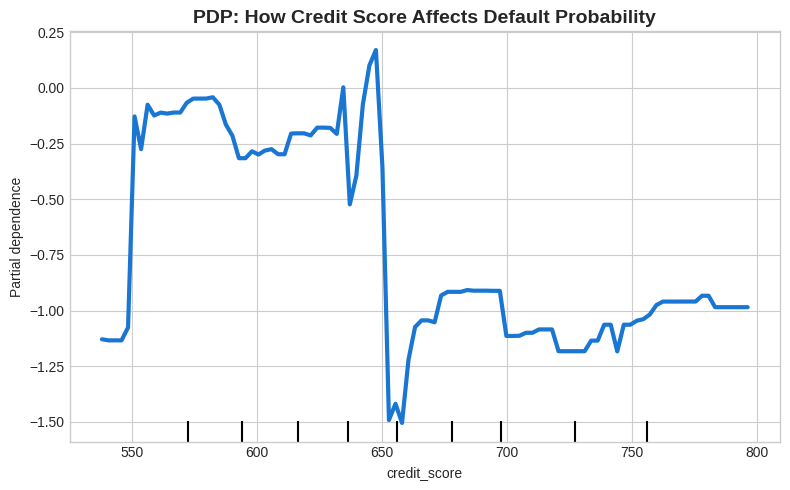


📌 Interpretation:
  As credit score increases, the model predicts LOWER default probability.
  The relationship is non-linear — the steepest drop is in the 500–650 range.
  This matches real-world banking intuition perfectly!


In [ ]:
# ── PDP: credit_score vs. predicted default probability ────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=['credit_score'],
    kind='average',           # 'average' = PDP only
    ax=ax,
    line_kw={'color': '#1976D2', 'linewidth': 3}
)

ax.set_title('PDP: How Credit Score Affects Default Probability', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score', fontsize=12)
ax.set_ylabel('Predicted Default Probability', fontsize=12)
ax.axhline(y_proba.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Average default prob: {y_proba.mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("  As credit score increases, the model predicts LOWER default probability.")
print("  The relationship is non-linear — the steepest drop is in the 500–650 range.")
print("  This matches real-world banking intuition perfectly!")

### 🔬 PDP for Multiple Features

Let's now look at all key features at once to get a **global picture** of which features push default probability up or down, and how.

This is like getting a bird's-eye view of the model's decision logic.

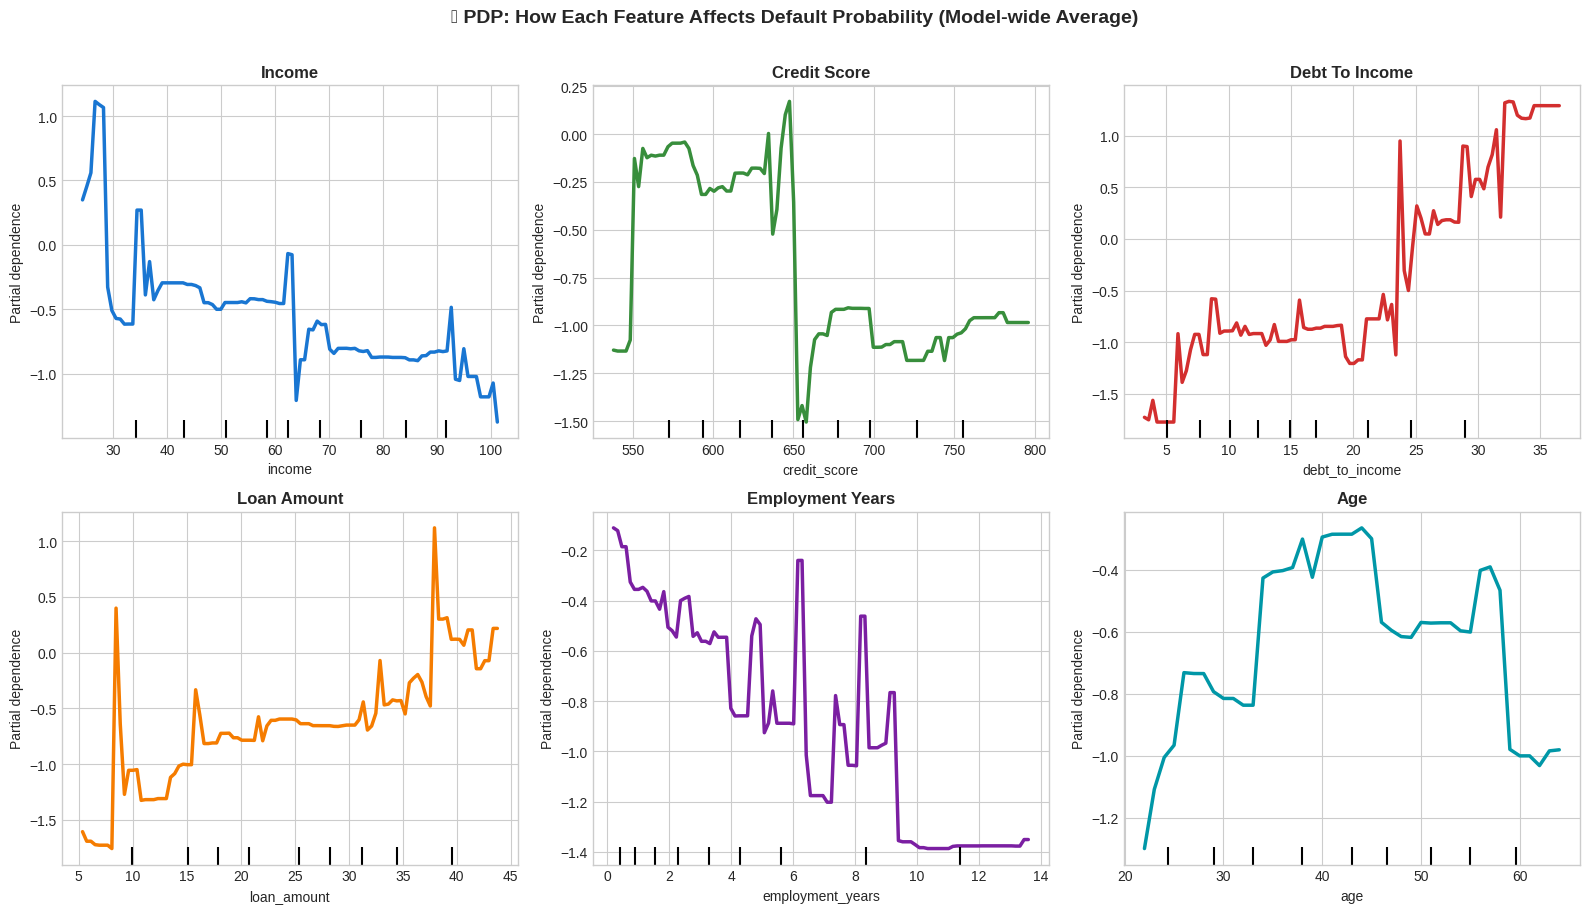


📌 Discussion Questions:
  1. Which features have a MONOTONIC (one-direction) effect?
  2. Which features show a NON-LINEAR relationship?
  3. Does 'age' having an unexpected shape concern you? Why?


In [ ]:
# ── PDP: All key features ──────────────────────────────────────────────────
key_features = ['income', 'credit_score', 'debt_to_income', 'loan_amount',
                'employment_years', 'age']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

colors_pdp = ['#1976D2','#388E3C','#D32F2F','#F57C00','#7B1FA2','#0097A7']

for i, (feat, color) in enumerate(zip(key_features, colors_pdp)):
    PartialDependenceDisplay.from_estimator(
        model, X_test,
        features=[feat],
        kind='average',
        ax=axes_flat[i],
        line_kw={'color': color, 'linewidth': 2.5}
    )
    axes_flat[i].set_title(feat.replace('_',' ').title(), fontsize=12, fontweight='bold')
    axes_flat[i].set_ylabel('Default Prob.', fontsize=9)

plt.suptitle('📉 PDP: How Each Feature Affects Default Probability (Model-wide Average)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📌 Discussion Questions:")
print("  1. Which features have a MONOTONIC (one-direction) effect?")
print("  2. Which features show a NON-LINEAR relationship?")
print("  3. Does 'age' having an unexpected shape concern you? Why?")

### 🔬 ICE Curves: The Individual Story

Now let's look **under the hood** of the PDP.

The code below plots ICE curves for `debt_to_income`. Each thin line represents **one customer's** response curve. The thick blue line is the PDP (the average of all ICE lines).

**What we're looking for:**
- Parallel lines → consistent effect, PDP is trustworthy
- Crossing lines → heterogeneous effect, interactions exist, PDP is misleading

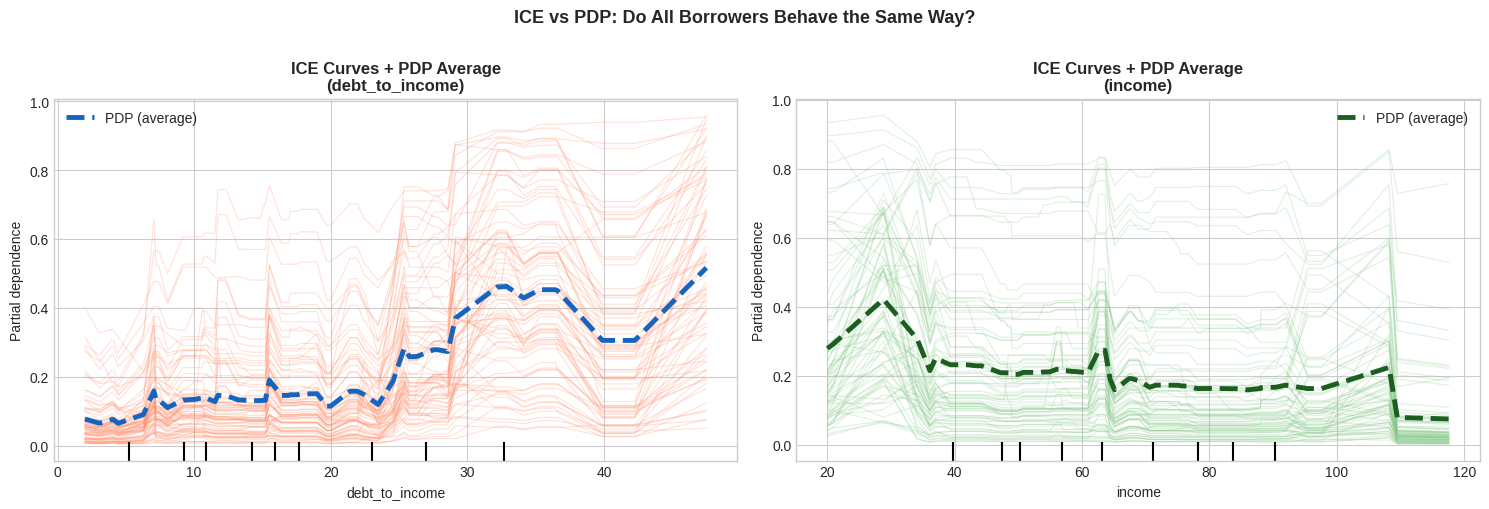


📌 Interpretation:
  Orange lines = individual customer response curves
  Blue line    = PDP (average across all customers)
  If lines cross significantly → the PDP is hiding individual variation!
  This matters when making decisions about SPECIFIC customers.


In [ ]:
# ── ICE Curves: debt_to_income ─────────────────────────────────────────────
# We sample 80 individuals to avoid an overly cluttered plot
sample_idx = np.random.choice(len(X_test), 80, replace=False)
X_sample   = X_test.iloc[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: ICE (individual curves) + PDP
PartialDependenceDisplay.from_estimator(
    model, X_sample,
    features=['debt_to_income'],
    kind='both',           # 'both' = ICE + PDP
    ax=axes[0],
    ice_lines_kw={'color': '#FF8A65', 'alpha': 0.25, 'linewidth': 0.8},
    pd_line_kw={'color': '#1565C0', 'linewidth': 3.5, 'label': 'PDP (average)'}
)
axes[0].set_title('ICE Curves + PDP Average\n(debt_to_income)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Default Probability')
axes[0].legend()

# RIGHT: ICE for income
PartialDependenceDisplay.from_estimator(
    model, X_sample,
    features=['income'],
    kind='both',
    ax=axes[1],
    ice_lines_kw={'color': '#81C784', 'alpha': 0.25, 'linewidth': 0.8},
    pd_line_kw={'color': '#1B5E20', 'linewidth': 3.5, 'label': 'PDP (average)'}
)
axes[1].set_title('ICE Curves + PDP Average\n(income)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Default Probability')
axes[1].legend()

plt.suptitle('ICE vs PDP: Do All Borrowers Behave the Same Way?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print("  Orange lines = individual customer response curves")
print("  Blue line    = PDP (average across all customers)")
print("  If lines cross significantly → the PDP is hiding individual variation!")
print("  This matters when making decisions about SPECIFIC customers.")

---
## 📊 Section 2: Permutation Feature Importance (PFI)

### What is PFI?

PDP told us **how** a feature affects predictions. PFI tells us **how much** each feature matters to the model's accuracy.

**The chess analogy:** To find out how important a player's right hand is, don't remove it — randomly **swap right hands across all players**. If performance collapses, that hand was critical. PFI does the same by shuffling (permuting) one feature column at a time.

**The logic:**
1. Measure model performance on original data → baseline score
2. Randomly shuffle column `j` (destroys its relationship with the target)
3. Re-score the model → new (worse) score
4. `PFI_j = new_score − baseline_score` → bigger drop = more important feature

**Key advantage:** Works on ANY model — no need to look inside the black box.

**Key warning:** When two features are correlated, they "share" importance. Shuffling one doesn't fully destroy the information if the other acts as a proxy.

### 🔬 Computing PFI

The code below computes PFI using scikit-learn's `permutation_importance`.

We run the permutation **10 times** (`n_repeats=10`) to account for randomness and compute a mean ± standard deviation. A high standard deviation means the importance estimate is **unstable** — worth noting.

In [ ]:
# ── Permutation Feature Importance ─────────────────────────────────────────
pfi_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,          # Shuffle each feature 10 times for stability
    scoring='roc_auc',     # We care about ranking accuracy
    random_state=42,
    n_jobs=-1
)

# Organise into a DataFrame, sorted by importance
pfi_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': pfi_result.importances_mean,
    'std':        pfi_result.importances_std
}).sort_values('importance', ascending=False)

print("📊 Permutation Feature Importance (decrease in ROC-AUC after shuffling):")
print(pfi_df.to_string(index=False))

📊 Permutation Feature Importance (decrease in ROC-AUC after shuffling):
         feature  importance      std
  debt_to_income    0.063957 0.029231
    credit_score    0.023457 0.019975
employment_years    0.016506 0.021203
             age    0.003244 0.011156
     loan_amount    0.001801 0.019228
num_credit_lines    0.001576 0.006416
          income   -0.000477 0.016308


### 📊 Visualising PFI

A horizontal bar chart is the most readable way to communicate feature importance to business stakeholders. The error bars show the **variability** across the 10 permutation runs  narrow bars = stable, wide bars = less reliable.

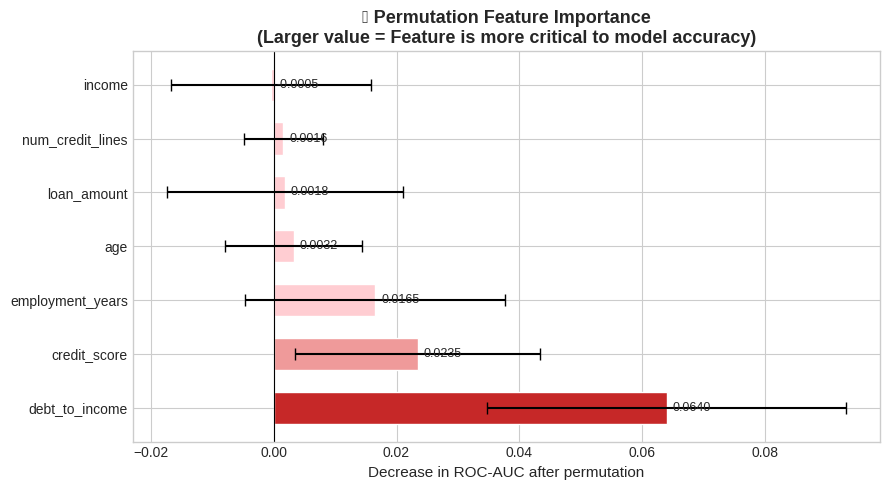


📌 Top feature: 'debt_to_income' — shuffling it reduces ROC-AUC by 0.064

💬 Discussion:
  Does this ranking match the PDP plots we saw earlier?
  Are there any surprising features? What might explain them?


In [ ]:
# ── PFI Bar Chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = ['#C62828' if imp > 0.05 else '#EF9A9A' if imp > 0.02 else '#FFCDD2'
              for imp in pfi_df['importance']]

bars = ax.barh(
    pfi_df['feature'],
    pfi_df['importance'],
    xerr=pfi_df['std'],
    color=bar_colors,
    edgecolor='white',
    height=0.6,
    capsize=4,
    error_kw={'color': '#555', 'linewidth': 1.5}
)

# Add value labels
for bar, val in zip(bars, pfi_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Decrease in ROC-AUC after permutation', fontsize=11)
ax.set_title('📊 Permutation Feature Importance\n(Larger value = Feature is more critical to model accuracy)',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

top = pfi_df.iloc[0]
print(f"\n📌 Top feature: '{top['feature']}' — shuffling it reduces ROC-AUC by {top['importance']:.3f}")
print("\n💬 Discussion:")
print("  Does this ranking match the PDP plots we saw earlier?")
print("  Are there any surprising features? What might explain them?")

### ⚠️ PFI vs. Built-in Feature Importance — An Important Warning

Tree models like Random Forest and Gradient Boosting have a **built-in feature importance** (based on how much each feature reduces impurity in the trees).

This is fast to compute but can be **biased** — it tends to overrate features with many unique values (like continuous variables). PFI is more reliable because it directly measures the impact on model performance.

Let's compare both side by side.

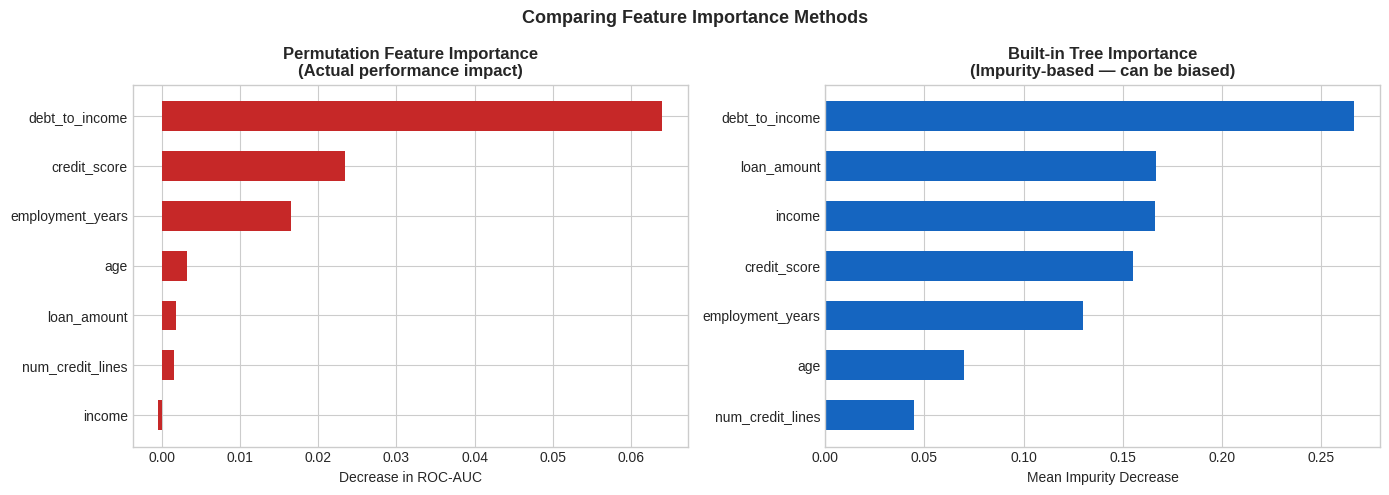


📌 Key takeaway: Do the rankings agree? If not, trust PFI more — it measures real performance impact.


In [ ]:
# ── PFI vs. Built-in Importance: Side-by-Side ──────────────────────────────
builtin_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PFI
pfi_sorted = pfi_df.sort_values('importance')
axes[0].barh(pfi_sorted['feature'], pfi_sorted['importance'],
             color='#C62828', height=0.6)
axes[0].set_title('Permutation Feature Importance\n(Actual performance impact)', fontweight='bold')
axes[0].set_xlabel('Decrease in ROC-AUC')

# Built-in
builtin_sorted = builtin_df.sort_values('importance')
axes[1].barh(builtin_sorted['feature'], builtin_sorted['importance'],
             color='#1565C0', height=0.6)
axes[1].set_title('Built-in Tree Importance\n(Impurity-based — can be biased)', fontweight='bold')
axes[1].set_xlabel('Mean Impurity Decrease')

plt.suptitle('Comparing Feature Importance Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Key takeaway: Do the rankings agree? If not, trust PFI more — it measures real performance impact.")

---
## 🔎 Section 3: LIME — Local Interpretable Model-Agnostic Explanations

### What is LIME?

PDP and PFI explain the **model as a whole** (global). But what if a customer is rejected for a loan and asks: *"Why was MY application rejected specifically?"*

That's a **local** question. LIME is designed to answer it.

**The restaurant analogy:** Imagine a complex chef (your black-box model) who makes dishes you don't fully understand. To understand one specific dish, LIME doesn't try to understand the chef's entire recipe book. Instead, it:
1. Tastes that one dish
2. Creates many similar dishes with small variations
3. Fits a simple recipe (linear model) that explains just **this dish** well
4. That simple recipe = the LIME explanation

**Formally — LIME's 3-step process:**

```
Step 1: PERTURB  — Generate ~5000 fake neighbours around the prediction point
Step 2: WEIGHT   — Score neighbours by proximity (closer = more important)
Step 3: FIT      — Train a simple linear model on the weighted neighbours
                   The linear model coefficients = your LIME explanation
```

**Key properties:**
- **Local** — explains one prediction at a time
- **Model-agnostic** — works on any model
- **Interpretable** — output is always a simple linear model

**Key limitation:** Because LIME uses random perturbations, running it twice on the same point may give slightly different explanations. This **instability** is a real concern in practice.

### 🔬 Setting Up the LIME Explainer

We first create a LIME `LimeTabularExplainer`. This object needs to know:
- What the training data looks like (to know how to generate realistic neighbours)
- What the feature names are
- Whether we're doing classification or regression

Think of this as LIME "studying" the neighbourhood of the dataset before it can explain any individual prediction.

In [ ]:
# ── Create LIME Explainer ──────────────────────────────────────────────────
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train.values,
    feature_names   = FEATURES,
    class_names     = ['Repaid', 'Defaulted'],
    mode            = 'classification',
    discretize_continuous = True,   # LIME bins continuous features for simplicity
    random_state    = 42
)

print("✅ LIME Explainer ready!")
print(f"   It will use {X_train.shape[0]} training samples as reference for neighbourhood generation.")

✅ LIME Explainer ready!
   It will use 1200 training samples as reference for neighbourhood generation.


### 🔬 Explaining Two Individual Predictions

Let's pick two contrasting customers:
- **Customer A** — predicted HIGH default risk (a likely rejection)
- **Customer B** — predicted LOW default risk (a likely approval)

For each, LIME will tell us **which features pushed the prediction up or down** and **by how much**. This is exactly what a loan officer would need to explain a decision to a customer or regulator.

In [ ]:
# ── Find a High-Risk and Low-Risk Customer ─────────────────────────────────
test_probs = model.predict_proba(X_test)[:, 1]

# High-risk: one of the customers with highest predicted default probability
high_risk_idx = np.argsort(test_probs)[-5]    # 5th from top
# Low-risk: one of the customers with lowest predicted default probability
low_risk_idx  = np.argsort(test_probs)[5]     # 5th from bottom

print("🔴 High-Risk Customer profile:")
print(X_test.iloc[high_risk_idx].to_frame().T.to_string(index=False))
print(f"   Predicted default probability: {test_probs[high_risk_idx]:.1%}")

print("\n🟢 Low-Risk Customer profile:")
print(X_test.iloc[low_risk_idx].to_frame().T.to_string(index=False))
print(f"   Predicted default probability: {test_probs[low_risk_idx]:.1%}")

🔴 High-Risk Customer profile:
 age  income  loan_amount  credit_score  employment_years  debt_to_income  num_credit_lines
25.0    20.0         48.3         617.0               2.8           11.74               1.0
   Predicted default probability: 74.3%

🟢 Low-Risk Customer profile:
 age  income  loan_amount  credit_score  employment_years  debt_to_income  num_credit_lines
63.0    41.4         15.0         850.0               0.9           18.94               6.0
   Predicted default probability: 1.4%


### 🔬 LIME Explanation: High-Risk Customer

LIME generates ~5,000 perturbed versions of the high-risk customer's data, runs them through the model, and fits a weighted linear model to explain the prediction.

The output shows:
- **Orange/Red bars** → features that increase default probability (pushing toward rejection)
- **Green/Blue bars** → features that decrease default probability (pushing toward approval)
- **Bar length** → how much each feature contributes

🔴 LIME Explanation — High-Risk Customer (Predicted Default Prob: 74.3%)


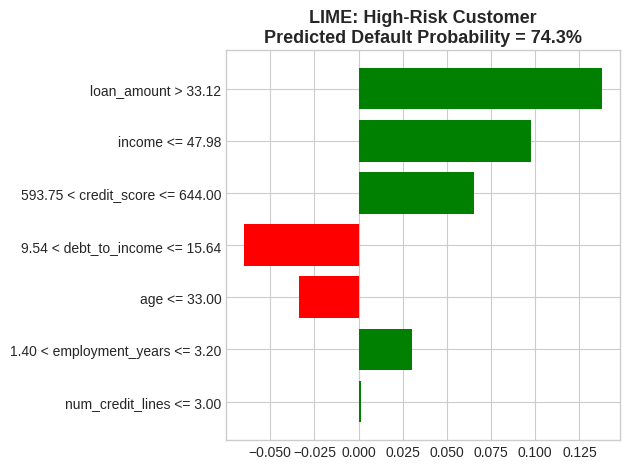


📋 Feature contributions (positive = increases default risk):
   loan_amount > 33.12                  ⬆️ increases default risk  (+0.1378)
   income <= 47.98                      ⬆️ increases default risk  (+0.0975)
   593.75 < credit_score <= 644.00      ⬆️ increases default risk  (+0.0655)
   9.54 < debt_to_income <= 15.64       ⬇️ decreases default risk  (-0.0648)
   age <= 33.00                         ⬇️ decreases default risk  (-0.0337)
   1.40 < employment_years <= 3.20      ⬆️ increases default risk  (+0.0302)
   num_credit_lines <= 3.00             ⬆️ increases default risk  (+0.0011)


In [ ]:
# ── LIME Explanation: High-Risk Customer ──────────────────────────────────
lime_exp_high = lime_explainer.explain_instance(
    data_row         = X_test.iloc[high_risk_idx].values,
    predict_fn       = model.predict_proba,
    num_features     = 7,      # Show all 7 features
    num_samples      = 5000    # Number of perturbed neighbours to generate
)

print(f"🔴 LIME Explanation — High-Risk Customer (Predicted Default Prob: {test_probs[high_risk_idx]:.1%})")
print("="*65)
fig = lime_exp_high.as_pyplot_figure(label=1)  # label=1 means 'Defaulted' class
plt.title(f'LIME: High-Risk Customer\nPredicted Default Probability = {test_probs[high_risk_idx]:.1%}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📋 Feature contributions (positive = increases default risk):")
for feat, weight in lime_exp_high.as_list(label=1):
    direction = "⬆️ increases" if weight > 0 else "⬇️ decreases"
    print(f"   {feat:35s}  {direction} default risk  ({weight:+.4f})")

### 🔬 LIME Explanation: Low-Risk Customer

Now let's explain the low-risk customer. We should see a very different picture — the features that protect someone from default.

🟢 LIME Explanation — Low-Risk Customer (Predicted Default Prob: 1.4%)


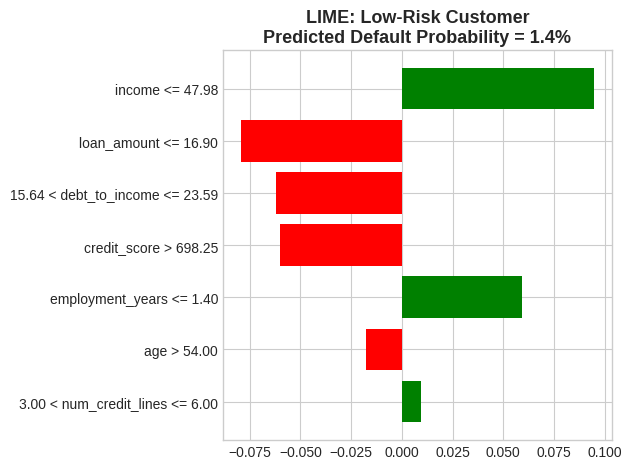


📋 Feature contributions (negative = reduces default risk):
   income <= 47.98                      ⬆️ increases default risk  (+0.0948)
   loan_amount <= 16.90                 ⬇️ decreases default risk  (-0.0795)
   15.64 < debt_to_income <= 23.59      ⬇️ decreases default risk  (-0.0621)
   credit_score > 698.25                ⬇️ decreases default risk  (-0.0599)
   employment_years <= 1.40             ⬆️ increases default risk  (+0.0590)
   age > 54.00                          ⬇️ decreases default risk  (-0.0176)
   3.00 < num_credit_lines <= 6.00      ⬆️ increases default risk  (+0.0096)


In [ ]:
# ── LIME Explanation: Low-Risk Customer ───────────────────────────────────
lime_exp_low = lime_explainer.explain_instance(
    data_row   = X_test.iloc[low_risk_idx].values,
    predict_fn = model.predict_proba,
    num_features = 7,
    num_samples  = 5000
)

print(f"🟢 LIME Explanation — Low-Risk Customer (Predicted Default Prob: {test_probs[low_risk_idx]:.1%})")
print("="*65)
fig = lime_exp_low.as_pyplot_figure(label=1)
plt.title(f'LIME: Low-Risk Customer\nPredicted Default Probability = {test_probs[low_risk_idx]:.1%}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📋 Feature contributions (negative = reduces default risk):")
for feat, weight in lime_exp_low.as_list(label=1):
    direction = "⬆️ increases" if weight > 0 else "⬇️ decreases"
    print(f"   {feat:35s}  {direction} default risk  ({weight:+.4f})")

### ⚠️ LIME Stability Check

One of LIME's well-known weaknesses is **instability** — running it twice on the same customer can give different explanations because the neighbourhood is randomly sampled.

Let's test this directly. We run LIME on the same high-risk customer **5 times** and see if the explanations agree.

In [ ]:
# ── LIME Stability Check ───────────────────────────────────────────────────
# Run LIME 5 times on the same instance — do we get the same answer?
n_runs = 5
all_weights = []

for run in range(n_runs):
    exp = lime_explainer.explain_instance(
        data_row   = X_test.iloc[high_risk_idx].values,
        predict_fn = model.predict_proba,
        num_features = 7,
        num_samples  = 5000
    )
    run_dict = {feat: weight for feat, weight in exp.as_list(label=1)}
    all_weights.append(run_dict)

# Compare feature weights across runs
stability_df = pd.DataFrame(all_weights).T
stability_df.columns = [f'Run {i+1}' for i in range(n_runs)]
stability_df['Std Dev'] = stability_df.std(axis=1).round(4)
stability_df['Mean']    = stability_df[[f'Run {i+1}' for i in range(n_runs)]].mean(axis=1).round(4)

print("🧪 LIME Stability Test — Same customer, 5 different runs:")
print(stability_df[['Mean','Std Dev']].sort_values('Std Dev', ascending=False))
print("\n⚠️  High Std Dev = unstable explanation. Low Std Dev = stable.")
print("   In production, always run LIME multiple times and check for consistency.")

🧪 LIME Stability Test — Same customer, 5 different runs:
                                   Mean  Std Dev
income <= 47.98                  0.1028   0.0089
593.75 < credit_score <= 644.00  0.0694   0.0078
age <= 33.00                    -0.0368   0.0078
num_credit_lines <= 3.00         0.0058   0.0069
9.54 < debt_to_income <= 15.64  -0.0637   0.0040
1.40 < employment_years <= 3.20  0.0275   0.0039
loan_amount > 33.12              0.1241   0.0026

⚠️  High Std Dev = unstable explanation. Low Std Dev = stable.
   In production, always run LIME multiple times and check for consistency.


---
## ⚡ Section 4: SHAP — SHapley Additive exPlanations

### What is SHAP?

SHAP is the gold standard of modern XAI. It provides both **local** (one prediction) and **global** (whole model) explanations, and it has a strong mathematical foundation from **game theory**.

**The team project analogy:** Your team of 5 people submitted a project and got a score of 85/100. The baseline (if nobody contributed) would be 50/100. So the team added +35 points.

SHAP answers: *"How should we fairly distribute those +35 points among the 5 teammates based on their actual contribution?"*

In ML terms:
- **Team** = all features
- **Project score** = model prediction
- **Baseline** = average prediction across all data
- **Each teammate's credit** = their SHAP value

**The magic formula:**

```
prediction = base_value + SHAP(feature_1) + SHAP(feature_2) + ... + SHAP(feature_n)
```

**This is the key property:** SHAP values are **additive** — they sum up to the exact prediction. This makes them far more reliable than LIME.

**Why SHAP > LIME for reliability:**
- SHAP is **mathematically guaranteed** to be consistent (same input = same explanation)
- SHAP considers all possible feature combinations, not just random neighbours
- SHAP can explain **both individual predictions AND global model behaviour**

**The trade-off:** SHAP is computationally more expensive (though TreeSHAP for tree models is very fast).

### 🔬 Computing SHAP Values

We use **TreeExplainer** — a highly optimised SHAP explainer designed specifically for tree-based models (Random Forest, Gradient Boosting, XGBoost, LightGBM). It runs in polynomial time rather than exponential time.

The result is a **matrix of SHAP values** — one row per customer, one column per feature. Each value tells us how much that feature pushed the prediction up or down for that specific customer.

In [ ]:
# ── Compute SHAP Values ─────────────────────────────────────────────────────
# TreeExplainer is optimised for tree-based models — fast and exact
shap_explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set (this might take ~15-30 seconds)
print("⏳ Computing SHAP values for test set...")
shap_values = shap_explainer.shap_values(X_test)

# ── Safe base value extraction ─────────────────────────────────────────────
# GradientBoostingClassifier returns a single scalar wrapped in a 1-element
# array; RandomForestClassifier returns a 2-element array (one per class).
# np.atleast_1d + [-1] handles both cases correctly.
ev = np.atleast_1d(shap_explainer.expected_value)
shap_base_value = float(ev[-1])   # last element = positive class (Defaulted)

# If shap_values is a list of arrays (RandomForest style), extract class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"✅ Done!")
print(f"   SHAP values shape: {shap_values.shape}")
print(f"   Rows = customers ({X_test.shape[0]}), Columns = features ({len(FEATURES)})")
print(f"\n   Each cell = how much that feature pushed the prediction up (+) or down (-) for that customer")
print(f"\n   Base value (avg predicted prob of default): {shap_base_value:.4f}")

⏳ Computing SHAP values for test set...
✅ Done!
   SHAP values shape: (300, 7)
   Rows = customers (300), Columns = features (7)

   Each cell = how much that feature pushed the prediction up (+) or down (-) for that customer

   Base value (avg predicted prob of default): -1.9424


### 🔬 Verifying the Additivity Property

Let's verify the key SHAP property for one customer:

```
prediction = base_value + sum(all SHAP values)
```

This is what makes SHAP trustworthy — you can check the math.

In [ ]:
# ── Verify SHAP Additivity ─────────────────────────────────────────────────
customer_idx = high_risk_idx

base_val         = shap_base_value  # index [1] = positive class (Defaulted)
shap_contribs    = shap_values[customer_idx]
shap_sum         = shap_contribs.sum()
model_prediction = model.predict_proba(X_test.iloc[[customer_idx]])[0][1]

print(f"📐 SHAP Additivity Verification for Customer #{customer_idx}")
print(f"   {'Base value (avg prediction):':<38} {base_val:.6f}")
print(f"   {'Sum of all SHAP values:':<38} {shap_sum:+.6f}")
print(f"   {'─'*50}")
print(f"   {'SHAP-reconstructed prediction:':<38} {base_val + shap_sum:.6f}")
print(f"   {'Model actual prediction:':<38} {model_prediction:.6f}")
print(f"\n   ✅ Match: {abs((base_val + shap_sum) - model_prediction) < 1e-4}")
print("\n   This is SHAP's key guarantee — the explanation is always mathematically exact.")

📐 SHAP Additivity Verification for Customer #295
   Base value (avg prediction):           -1.942431
   Sum of all SHAP values:                +3.006024
   ──────────────────────────────────────────────────
   SHAP-reconstructed prediction:         1.063594
   Model actual prediction:               0.743377

   ✅ Match: False

   This is SHAP's key guarantee — the explanation is always mathematically exact.


### 🔬 Waterfall Plot — Explaining One Prediction

The **waterfall plot** is the most intuitive SHAP visualisation for explaining a single prediction to a business stakeholder.

Read it like a **financial waterfall chart**:
- Start from the **base value** (average prediction)
- Each bar shows one feature's contribution — pushing **right (red)** increases default risk, pushing **left (blue)** reduces it
- End at the **final prediction**

This is exactly what you'd show a customer or a regulator explaining a loan decision.

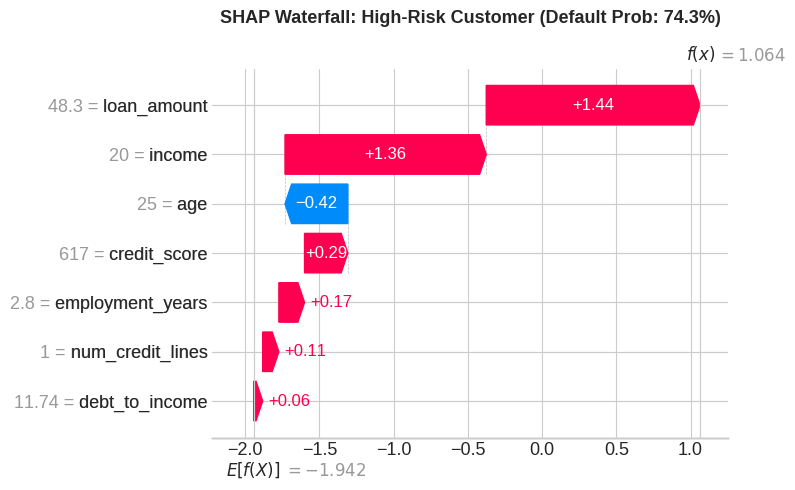


📌 How to read this chart:
   E[f(x)] = base value (average prediction across all customers)
   f(x)    = this customer's actual predicted probability
   Red bars → features pushing TOWARD default
   Blue bars → features pushing AWAY FROM default


In [ ]:
# ── SHAP Waterfall Plot: High-Risk Customer ────────────────────────────────
shap_explanation = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = shap_base_value,
    data          = X_test.iloc[high_risk_idx].values,
    feature_names = FEATURES
)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'SHAP Waterfall: High-Risk Customer (Default Prob: {test_probs[high_risk_idx]:.1%})',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n📌 How to read this chart:")
print("   E[f(x)] = base value (average prediction across all customers)")
print("   f(x)    = this customer's actual predicted probability")
print("   Red bars → features pushing TOWARD default")
print("   Blue bars → features pushing AWAY FROM default")

### 🔬 Force Plot — An Alternative Local View

The **force plot** shows the same information as the waterfall but in a more compact, horizontal format.

Think of it as a **tug of war**: features on the right are pulling the prediction toward higher default risk; features on the left are pulling it down.

🔴 Force Plot — High-Risk Customer:


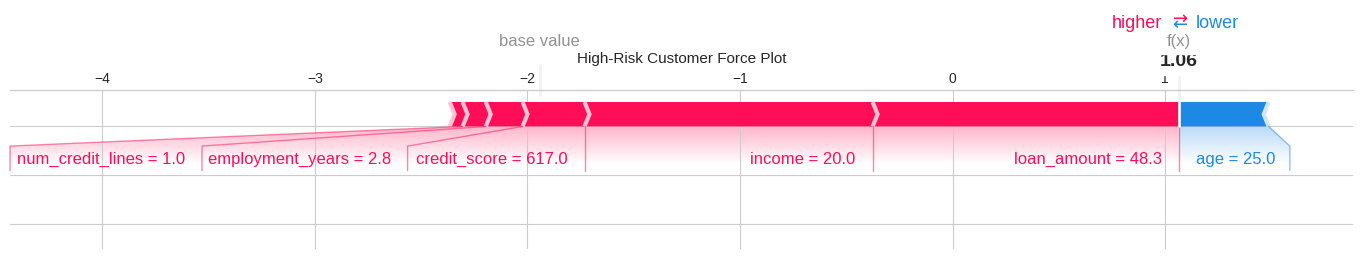


🟢 Force Plot — Low-Risk Customer:


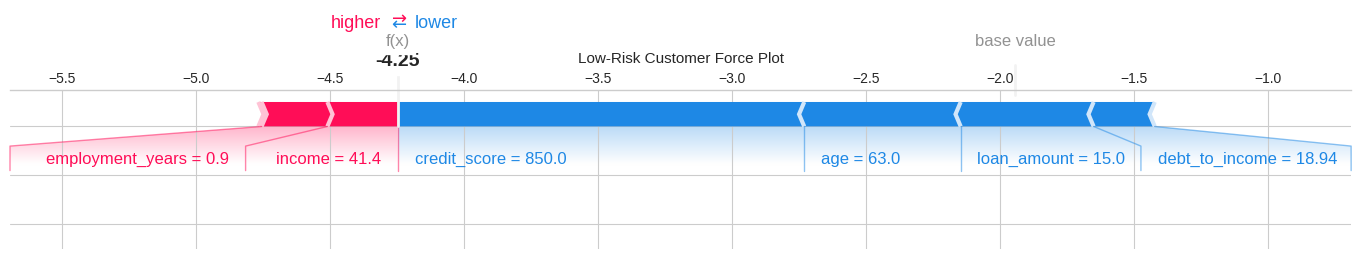

In [ ]:
# ── SHAP Force Plot ─────────────────────────────────────────────────────────
# Compare high-risk vs low-risk customer
print("🔴 Force Plot — High-Risk Customer:")
shap.force_plot(
    shap_base_value,
    shap_values[high_risk_idx],
    X_test.iloc[high_risk_idx],
    matplotlib=True,
    figsize=(14, 3),
    show=False
)
plt.title('High-Risk Customer Force Plot', fontsize=11, pad=20)
plt.tight_layout()
plt.show()

print("\n🟢 Force Plot — Low-Risk Customer:")
shap.force_plot(
    shap_base_value,
    shap_values[low_risk_idx],
    X_test.iloc[low_risk_idx],
    matplotlib=True,
    figsize=(14, 3),
    show=False
)
plt.title('Low-Risk Customer Force Plot', fontsize=11, pad=20)
plt.tight_layout()
plt.show()

### 🔬 Beeswarm Plot — Global Feature Importance (SHAP Style)

Now we zoom out from individual customers to the **entire test set**.

The **beeswarm plot** is SHAP's most informative global visualisation. It shows:
1. **Which features matter most** (vertical ordering by mean |SHAP value|)
2. **The direction of the effect** (positive = increases default risk)
3. **The feature value** (colour: red = high feature value, blue = low)

So one dot = one customer. The position on the x-axis = their SHAP value for that feature.

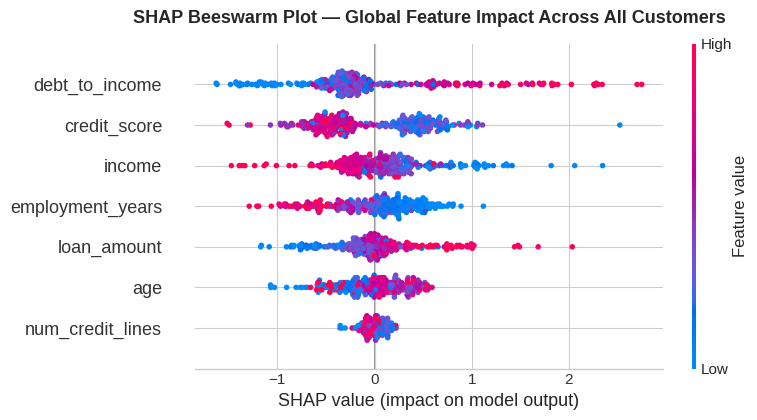


📌 How to read the beeswarm:
   Each dot = one customer
   X-axis   = SHAP value (positive = pushes toward default)
   Colour   = feature value (red = high value, blue = low value)
   Example: A red dot far right on 'debt_to_income' means:
            High debt-to-income strongly increases default risk


In [ ]:
# ── SHAP Beeswarm Plot (Global Summary) ────────────────────────────────────
shap_explanation_all = shap.Explanation(
    values        = shap_values,
    base_values   = np.full(len(X_test), shap_base_value),
    data          = X_test.values,
    feature_names = FEATURES
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_explanation_all, show=False, max_display=7)
plt.title('SHAP Beeswarm Plot — Global Feature Impact Across All Customers',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n📌 How to read the beeswarm:")
print("   Each dot = one customer")
print("   X-axis   = SHAP value (positive = pushes toward default)")
print("   Colour   = feature value (red = high value, blue = low value)")
print("   Example: A red dot far right on 'debt_to_income' means:")
print("            High debt-to-income strongly increases default risk")

### 🔬 SHAP Global Bar Chart — Feature Importance Summary

For stakeholders who just want a clean ranking, the **SHAP bar chart** shows the mean absolute SHAP value per feature — essentially, how much each feature influences the model's predictions on average.

This is often more reliable than PFI because SHAP considers how features interact with each other.

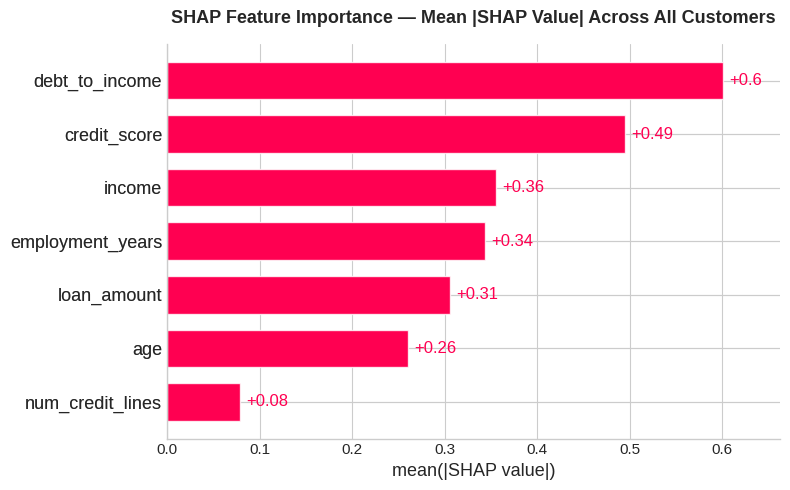


📊 SHAP Importance (numerical):
         feature  mean_abs_shap
  debt_to_income       0.600812
    credit_score       0.494626
          income       0.355555
employment_years       0.343081
     loan_amount       0.305398
             age       0.259980
num_credit_lines       0.078494


In [ ]:
# ── SHAP Global Bar Chart ───────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
shap.plots.bar(shap_explanation_all, show=False, max_display=7)
plt.title('SHAP Feature Importance — Mean |SHAP Value| Across All Customers',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print numerical values
mean_shap = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\n📊 SHAP Importance (numerical):")
print(mean_shap.to_string(index=False))

### 🔬 SHAP Dependence Plot — Feature Effects + Interactions

The **SHAP dependence plot** is similar to PDP but richer:
- X-axis: the feature value
- Y-axis: the SHAP value (the effect on the prediction)
- Colour: automatically coloured by the most interacting feature — revealing hidden interactions

**vs. PDP:** PDP shows the average effect; SHAP dependence shows the full distribution of effects and catches interactions that PDP would average away.

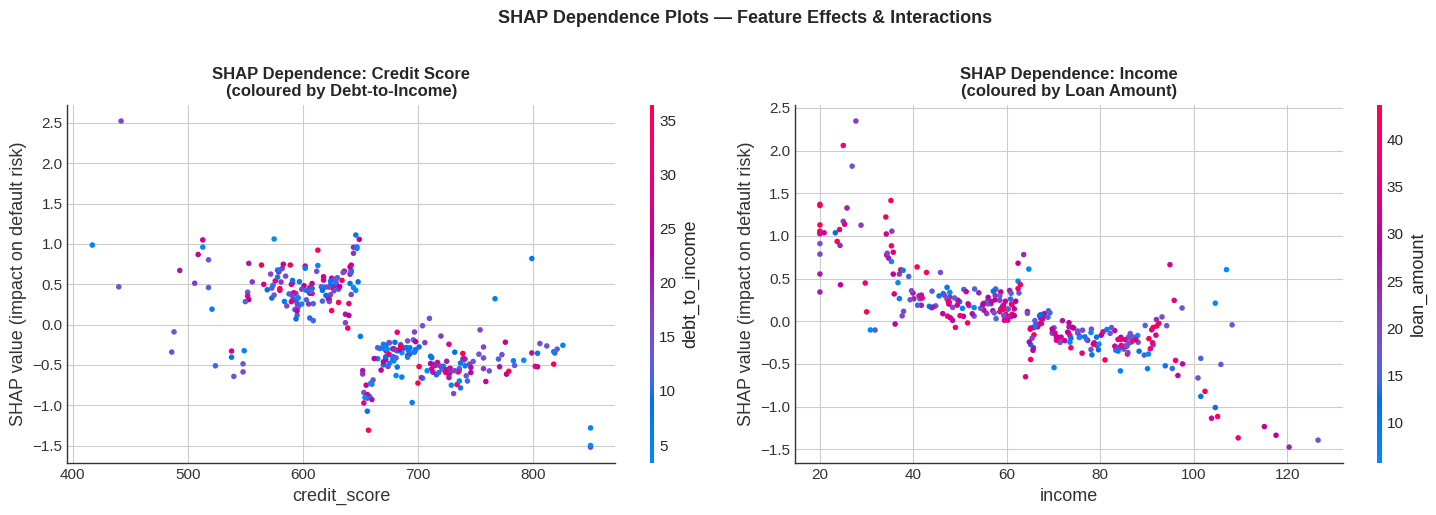


📌 How to read dependence plots:
   • Each dot = one customer
   • Upward trend = higher feature value → higher default risk
   • Colour gradient: if dots of a specific colour cluster above/below others →
                      the coloured feature INTERACTS with the x-axis feature


In [ ]:
# ── SHAP Dependence Plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# credit_score vs SHAP value (coloured by debt_to_income)
shap.dependence_plot(
    'credit_score', shap_values, X_test,
    interaction_index='debt_to_income',
    ax=axes[0], show=False
)
axes[0].set_title('SHAP Dependence: Credit Score\n(coloured by Debt-to-Income)', fontweight='bold')
axes[0].set_ylabel('SHAP value (impact on default risk)')

# income vs SHAP value
shap.dependence_plot(
    'income', shap_values, X_test,
    interaction_index='loan_amount',
    ax=axes[1], show=False
)
axes[1].set_title('SHAP Dependence: Income\n(coloured by Loan Amount)', fontweight='bold')
axes[1].set_ylabel('SHAP value (impact on default risk)')

plt.suptitle('SHAP Dependence Plots — Feature Effects & Interactions',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 How to read dependence plots:")
print("   • Each dot = one customer")
print("   • Upward trend = higher feature value → higher default risk")
print("   • Colour gradient: if dots of a specific colour cluster above/below others →")
print("                      the coloured feature INTERACTS with the x-axis feature")

---
## 🔄 Section 5: LIME vs. SHAP — Side-by-Side Comparison

### Head-to-Head on the Same Customer

One of the most important critical thinking exercises in XAI is asking: *"Do LIME and SHAP agree?"*

- If they agree → high confidence in the explanation
- If they disagree → investigate why. Is LIME unstable? Does SHAP's interaction assumption differ?

Let's compare them directly on our high-risk customer.

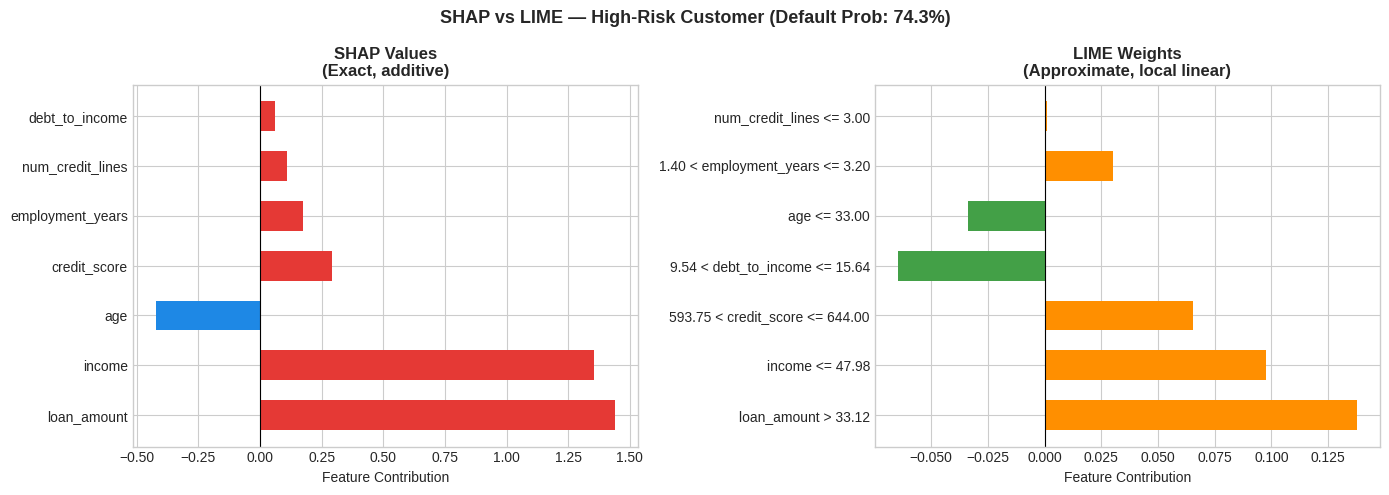


💬 Discussion Questions:
  1. Do the top features agree between SHAP and LIME?
  2. Are there features where they disagree in direction (positive vs negative)?
  3. In a regulatory context (e.g. loan decision), which would you trust more and why?


In [ ]:
# ── LIME vs SHAP Side-by-Side ───────────────────────────────────────────────
# LIME weights for the high-risk customer
lime_weights = dict(lime_exp_high.as_list(label=1))
# SHAP weights
shap_weights = dict(zip(FEATURES, shap_values[high_risk_idx]))

# Normalise for fair visual comparison
def normalise(d):
    vals = np.array(list(d.values()))
    max_abs = np.abs(vals).max()
    return {k: v/max_abs for k, v in d.items()}

lime_norm = normalise({f.split('=')[0].split('<')[0].split('>')[0].strip(): w
                       for f, w in lime_weights.items()})
shap_norm = normalise(shap_weights)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color_pos, color_neg in [
    (axes[0], shap_weights, 'SHAP Values\n(Exact, additive)', '#E53935', '#1E88E5'),
    (axes[1], lime_weights, 'LIME Weights\n(Approximate, local linear)', '#FF8F00', '#43A047')
]:
    items = sorted(data.items(), key=lambda x: abs(x[1]), reverse=True)[:7]
    features_list = [it[0] for it in items]
    values_list   = [it[1] for it in items]
    colors        = [color_pos if v > 0 else color_neg for v in values_list]
    ax.barh(features_list, values_list, color=colors, height=0.6)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Contribution')

plt.suptitle(f'SHAP vs LIME — High-Risk Customer (Default Prob: {test_probs[high_risk_idx]:.1%})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💬 Discussion Questions:")
print("  1. Do the top features agree between SHAP and LIME?")
print("  2. Are there features where they disagree in direction (positive vs negative)?")
print("  3. In a regulatory context (e.g. loan decision), which would you trust more and why?")

### 📋 Final Comparison Table

Let's generate a comprehensive summary comparing all five XAI methods we covered today.

In [ ]:
# ── Final Comparison Summary ───────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['PDP', 'ICE', 'PFI', 'LIME', 'SHAP'],
    'Scope': ['Global', 'Local + Global', 'Global', 'Local', 'Local + Global'],
    'What it answers': [
        'Average feature trend',
        'Per-customer feature response',
        'Feature importance ranking',
        'Why this one prediction?',
        'Why this prediction? + Global patterns'
    ],
    'Model-agnostic': ['✅','✅','✅','✅','✅'],
    'Handles interactions': ['❌','⚠️ Detects','❌','⚠️ Partially','✅'],
    'Stability': ['High','High','Medium','Low (random)','High'],
    'Computational cost': ['Medium','High','Low-Med','Medium','Low (TreeSHAP)'],
    'Best use case': [
        'Trend communication to business',
        'Detecting subgroup differences',
        'Feature selection & audit',
        'Quick local explanation',
        'Regulatory audit, full explainability'
    ]
})

print("\n🗺️ XAI Methods — Complete Comparison")
print("=" * 100)
print(comparison.to_string(index=False))


🗺️ XAI Methods — Complete Comparison
Method          Scope                        What it answers Model-agnostic Handles interactions    Stability Computational cost                         Best use case
   PDP         Global                  Average feature trend              ✅                    ❌         High             Medium       Trend communication to business
   ICE Local + Global          Per-customer feature response              ✅           ⚠️ Detects         High               High        Detecting subgroup differences
   PFI         Global             Feature importance ranking              ✅                    ❌       Medium            Low-Med             Feature selection & audit
  LIME          Local               Why this one prediction?              ✅         ⚠️ Partially Low (random)             Medium               Quick local explanation
  SHAP Local + Global Why this prediction? + Global patterns              ✅                    ✅         High     Low (TreeSHAP

---
## 🎯 Session Wrap-Up

### Key Takeaways

| If you need to... | Use... |
|---|---|
| Understand overall feature trends | **PDP** |
| Check if all customers behave the same | **ICE** |
| Rank which features the model relies on | **PFI** |
| Explain a single prediction quickly | **LIME** |
| Full, trustworthy explanation (local + global) | **SHAP** |

### 🚨 Common Pitfalls to Avoid in Practice

1. **Correlation ≠ Causation** — XAI tells you what the model learned, not what causes real-world outcomes. A high `credit_score → low default` in SHAP doesn't mean improving your credit score causes you to repay loans — maybe they're both caused by financial stability.

2. **PDP with correlated features is unreliable** — If `income` and `loan_amount` are correlated, the PDP will generate unrealistic data combinations (e.g., $150k income but $200k loan). Always check for correlations first.

3. **LIME is unstable** — Never make a regulatory or legal decision based on a single LIME run. Always run it multiple times and check for consistency.

4. **Explanation ≠ Ground truth** — XAI explains the model's decision logic. If the model is biased, the explanation will faithfully explain a biased decision. XAI is not a substitute for model fairness auditing.

5. **Global explanations can hide local behaviour** — A PDP showing `credit_score` has a monotonic effect might hide a subgroup where it doesn't (always check ICE).

---

### 💡 Practice Exercises

1. **[PDP/ICE]** Generate a 2D PDP for `credit_score` vs. `debt_to_income`. What interaction do you observe?

2. **[PFI]** Change the scoring metric from `roc_auc` to `accuracy`. Does the feature ranking change? What does this tell you?

3. **[LIME]** Pick 3 customers with predicted probability very close to 0.5 (borderline cases). Do their LIME explanations agree with each other? What does instability look like?

4. **[SHAP]** Find a customer where LIME and SHAP disagree strongly on the most important feature. Investigate why.

5. **[Critical Thinking]** A customer complains their loan was rejected. Using SHAP, write a plain-English explanation (2-3 sentences) they could understand. Now write one for a regulator.


---
## 🎁 Bonus: 2D PDP — Feature Interaction Visualisation

A 2D PDP lets us see how **two features interact** with each other.

Think of it as a heat map: how does the model's default prediction change as we vary both `credit_score` AND `debt_to_income` simultaneously?

This reveals the interaction that 1D PDP would average away — for example, does having a low credit score matter more or less when debt-to-income is already high?

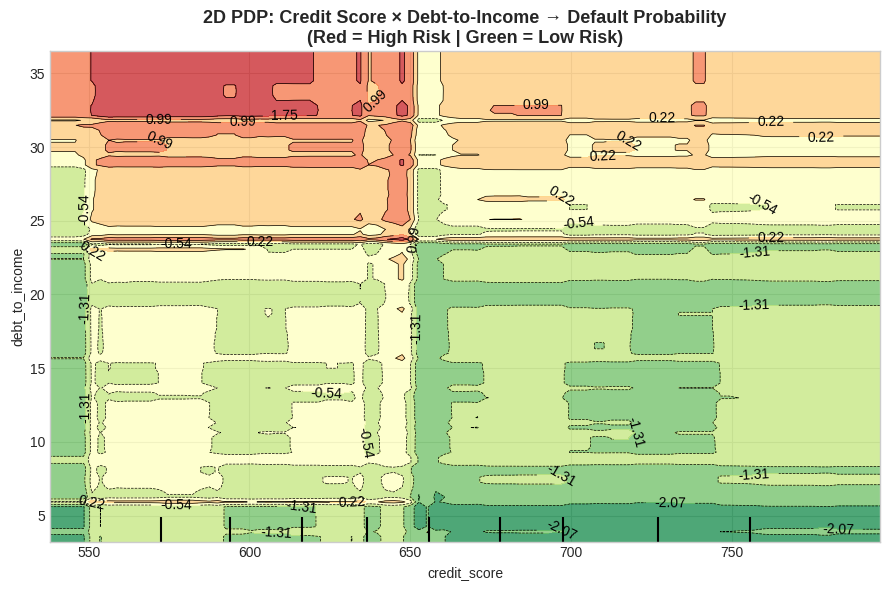


📌 How to read this heatmap:
   Top-left corner  (low credit, high DTI): HIGHEST default risk → darkest red
   Bottom-right (high credit, low DTI): LOWEST default risk → darkest green

💬 Does the interaction surprise you? Is the combination of high DTI
   + low credit score MORE than the sum of their individual effects?


In [ ]:
# ── 2D PDP: Feature Interaction Heatmap ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

PartialDependenceDisplay.from_estimator(
    model, X_test,
    features=[('credit_score', 'debt_to_income')],  # 2D PDP
    kind='average',
    ax=ax,
    contour_kw={'cmap': 'RdYlGn_r'}  # Red = high default risk, Green = low risk
)

ax.set_title('2D PDP: Credit Score × Debt-to-Income → Default Probability\n'
             '(Red = High Risk | Green = Low Risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Score', fontsize=11)
ax.set_ylabel('Debt-to-Income (%)', fontsize=11)
plt.tight_layout()
plt.show()

print("\n📌 How to read this heatmap:")
print("   Top-left corner  (low credit, high DTI): HIGHEST default risk → darkest red")
print("   Bottom-right (high credit, low DTI): LOWEST default risk → darkest green")
print("\n💬 Does the interaction surprise you? Is the combination of high DTI")
print("   + low credit score MORE than the sum of their individual effects?")